# Matplotlib Figures and Axes

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

x = np.linspace(0, 10, 50)
y = np.sin(x)

```{contents}
:local:
:depth: 2
```


```{index} object-oriented interface, figure, axes
```
## Object-Oriented Plotting with `plt.subplots()`


::: {note}
But what's the difference between a **figure** and an **axes**?

| | **Figure** | **Axes** |
|---|---|---|
| Analogy | The full canvas/window | One plot region on that canvas |
| What it is | The top-level container | The area where data is drawn |
| Contains | One or more Axes | X/Y axis, ticks, lines, labels, title, legend |
| Commonly created by | `plt.figure()` or `plt.subplots()` | returned by `plt.subplots()` or added to a figure |

A good mental model is:

```text
Figure
└── Axes (a.k.a. one plot)
    ├── XAxis
    ├── YAxis
    ├── Title
    ├── Lines / Bars / etc.
    └── Legend
```
:::



Here we will learn two OO workflows:

- `plt.subplots()` for the standard, everyday workflow
- `plt.figure()` + `fig.add_axes()` for manual placement and inset-style layouts



```{index} subplots (plt.subplots), tight layout (tight_layout), figure title (suptitle), shared axis (sharey)
```
### `plt.subplots()`

`plt.subplots()` creates the **figure** and **axes** objects in one step and returns them as a tuple.

- If you create a single subplot, you typically get one `Axes` object.
- If you create multiple subplots, you get a NumPy array of `Axes` objects.

Typical syntax:

`fig, ax = plt.subplots()`

The example below shows the standard one-axes case.


Text(0.5, 1.0, 'Title via Object-Oriented API')

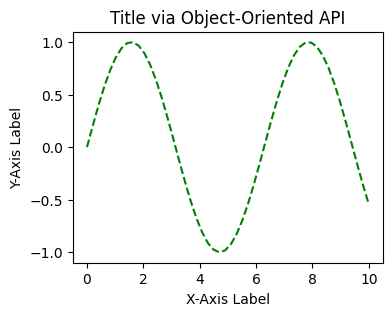

In [2]:
x = np.linspace(0, 10, 50)              ### start, stop, number of points
y = np.sin(x)

# fig, ax = plt.subplots()              ### single Axes case
# fig, axes = plt.subplots(1, 2)        ### multiple Axes case

fig, ax = plt.subplots(figsize=(4,3))   ### unpacking in one step
ax.plot(x, y, 'g--')                    ### plot on that axes

### common axes methods
ax.set_xlabel('X-Axis Label')
ax.set_ylabel('Y-Axis Label')
ax.set_title('Title via Object-Oriented API')


With `subplots()`, you can specify the number of rows and columns using the `nrows=` and `ncols=` parameters when creating the subplots() object. The example below creates an empty canvas of 1-row by 2-cols subplots. 

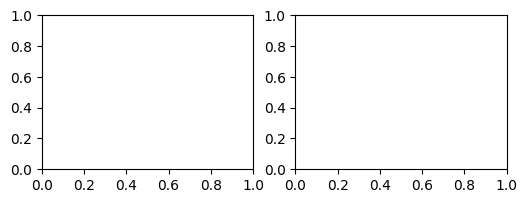

In [3]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(6, 2))  ### similar to plt.subplot(1, 2, ith axes)
# fig, axes = plt.subplots(1, 2)            ### same as above

In this example above, `axes` is an array variable containing two `Axes` objects. Looping over that array is a common pattern when you want to apply the same formatting to each subplot.

In [4]:
print(axes)

[<Axes: > <Axes: >]


Now we have access over the two Axes individually using **indexing** (`[0] and [1]`). We may plot them separately.

Text(0.5, 1.0, 'Second Plot')

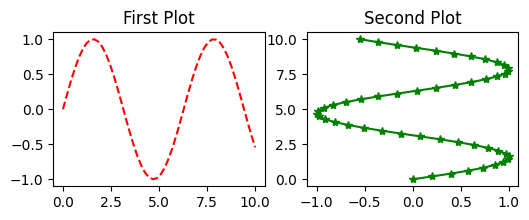

In [5]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(6, 2))  

axes[0].plot(x, y, 'r--')    ### plot on the first axes
axes[0].set_title('First Plot')  ### set title for the first axes   

axes[1].plot(y, x, 'g*-')    ### plot on the second axes
axes[1].set_title('Second Plot')  ### set title for the second axes

# plt.show()

It's not uncommon to loop through the Axes object then fine tune the plots.

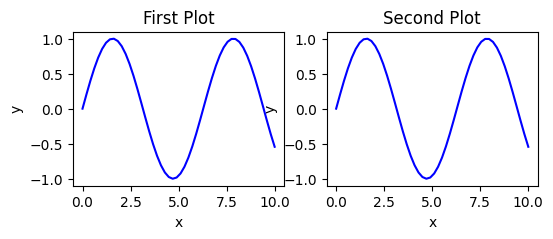

In [6]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(6, 2))  

for ax in axes:
    ax.plot(x, y, 'b')
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    ax.set_title('title')

axes[0].set_title('First Plot')  ### set title for the first axes
axes[1].set_title('Second Plot')  ### set title for the second axes
### display the figure object    
# fig                             ### to show the figure in some environments
plt.show()


A common issue in Matplotlib is overlapping subplot labels or titles. `plt.tight_layout()` can automatically adjust spacing so the figure is easier to read. (compare with the plots above)


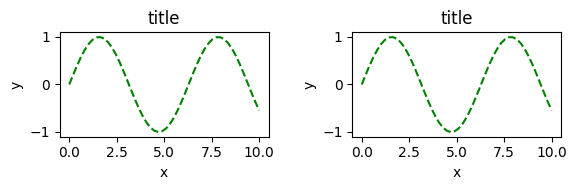

In [7]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(6, 2))  ### similar to plt.subplot(1, 2, ith axes)

for ax in axes:
    ax.plot(x, y, 'g--')
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    ax.set_title('title')

fig    
plt.tight_layout()

Each `ax.set_title()` names one axes. To give the whole figure one title, use `fig.suptitle()`, which places the title above all the subplots. This is common in dashboards, where several charts support one message. The x values here are quarter labels rather than numbers; Matplotlib places text labels along the axis in the order given. `sharey=True` gives every subplot the same y-axis range. Without it, each subplot scales to its own data, and a small region can look as large as a big one.


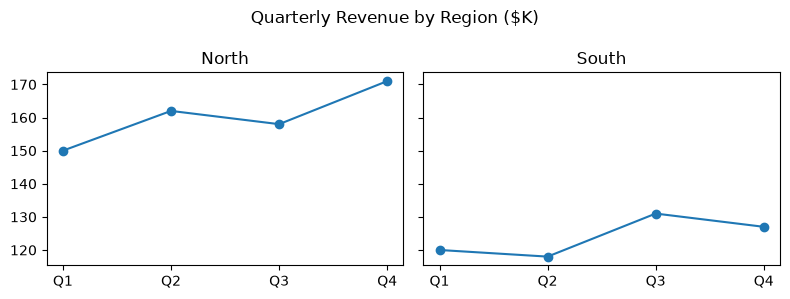

In [8]:
quarters = ["Q1", "Q2", "Q3", "Q4"]
north = [150, 162, 158, 171]
south = [120, 118, 131, 127]

fig, axes = plt.subplots(1, 2, figsize=(8, 3), sharey=True)   ### sharey: same y scale for a fair comparison

axes[0].plot(quarters, north, marker='o')
axes[0].set_title('North')

axes[1].plot(quarters, south, marker='o')
axes[1].set_title('South')

fig.suptitle('Quarterly Revenue by Region ($K)')   ### one title for the whole figure
plt.tight_layout()


In [8]:
### Exercise: Side-by-Side Subplots with plt.subplots()
#   1. Use plt.subplots(1, 2, figsize=(8, 3)) to create a figure and two axes.
#   2. On axes[0], plot x vs np.sin(x) with 'b-', title "Sine",
#      x-label "x", and y-label "y".
#   3. On axes[1], plot x vs np.cos(x) with 'r--', title "Cosine",
#      x-label "x", and y-label "y".
#   4. Call plt.tight_layout() at the end.
#   (`x` and `np` are already available above.)
### Your code starts here.




### Your code ends here.

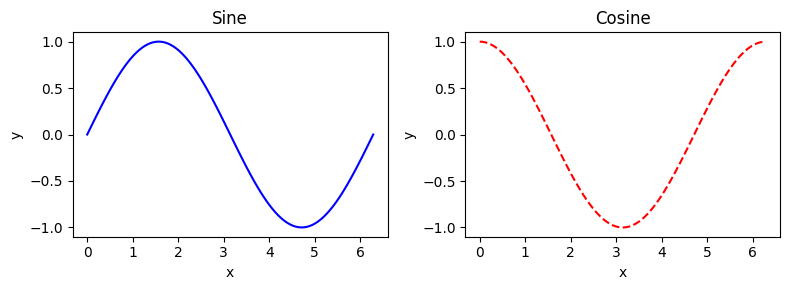

In [9]:
### Solution
import numpy as np
import matplotlib.pyplot as plt

x = np.linspace(0, 2 * np.pi, 100)
fig, axes = plt.subplots(1, 2, figsize=(8, 3))
axes[0].plot(x, np.sin(x), 'b-')
axes[0].set_title('Sine')
axes[0].set_xlabel('x')
axes[0].set_ylabel('y')
axes[1].plot(x, np.cos(x), 'r--')
axes[1].set_title('Cosine')
axes[1].set_xlabel('x')
axes[1].set_ylabel('y')
plt.tight_layout()
plt.show()


```{index} add axes (add_axes), inset axes
```
## Manual Placement with `add_axes()`

`fig.add_axes()` is a more manual OO technique than `plt.subplots()`. It is most useful when you want precise axes placement, such as inset plots or custom layouts.

The process of using `add_axes()` to create plots is:

1. Create a **Figure** object.
2. Add one or more **Axes** using normalized figure coordinates `[left, bottom, width, height]`.
3. Plot and format each axes separately.


`add_axes()` uses normalized figure coordinates. For example, `[0.1, 0.1, 0.8, 0.8]` means:

- left edge at 10% of the figure width
- bottom edge at 10% of the figure height
- axes width equal to 80% of the figure width
- axes height equal to 80% of the figure height


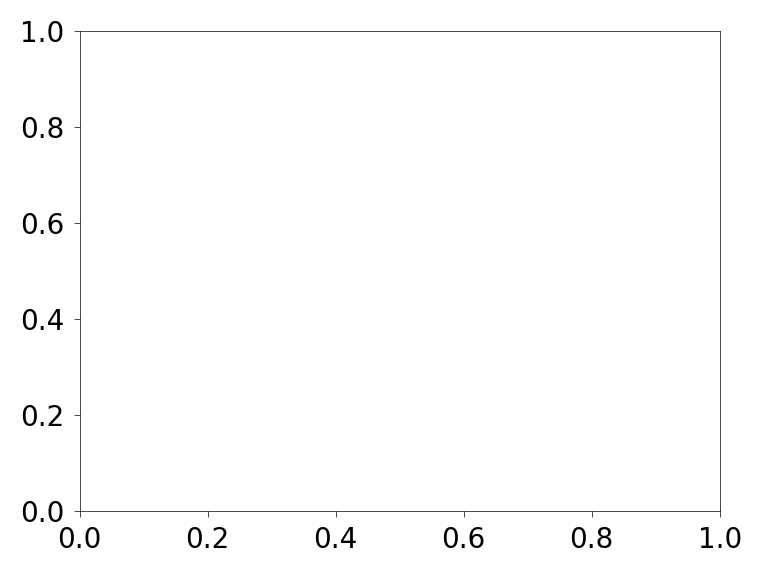

In [30]:
fig = plt.figure(figsize=(4,3))             ### 1. create an empty figure
ax = fig.add_axes([0.1, 0.1, 0.8, 0.8])     ### 2. add one axes using normalized coordinates



While slightly more involved, `add_axes()` gives you precise control over where each axes sits in the figure. That makes it a good choice for inset plots and manually arranged layouts.


Text(0.5, 1.0, 'Axes 2 Title')

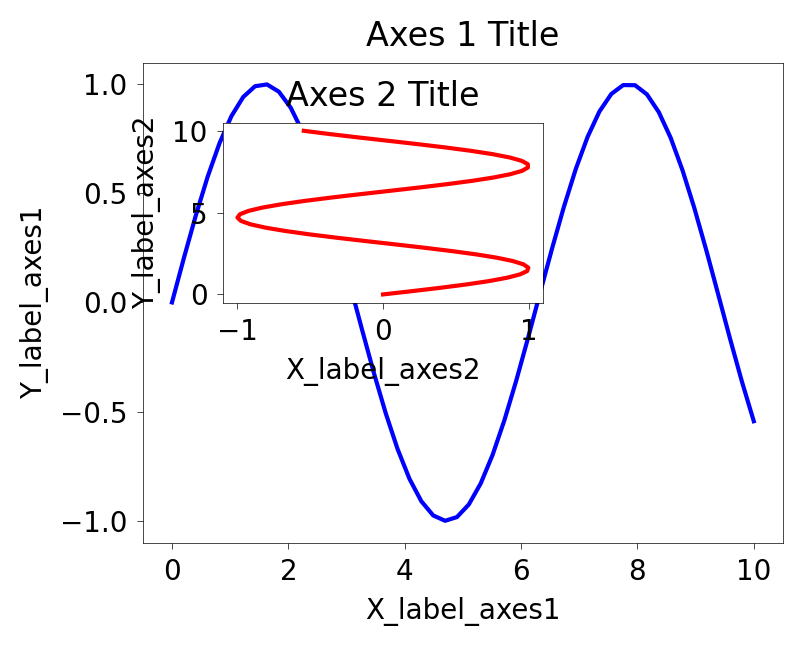

In [31]:
x = np.linspace(0, 10, 50)              ### start, stop, number of points
y = np.sin(x)

fig = plt.figure(figsize=(4,3))         ### create empty canvas on the figure (object)

### add two axes to the figure
axes1 = fig.add_axes([0.1, 0.1, 0.8, 0.8])     ### main axes
axes2 = fig.add_axes([0.2, 0.5, 0.4, 0.3])     ### insert axes

### larger figure Axes 1
axes1.plot(x, y, 'b')
axes1.set_xlabel('X_label_axes1')
axes1.set_ylabel('Y_label_axes1')
axes1.set_title('Axes 1 Title')

### insert figure Axes 2
axes2.plot(y, x, 'r')
axes2.set_xlabel('X_label_axes2')
axes2.set_ylabel('Y_label_axes2')
axes2.set_title('Axes 2 Title')

In [32]:
### Exercise: Figure with Main Plot and Inset using plt.figure()
#   1. Create a figure with figsize=(4, 3).
#   2. Add a main axes at [0.1, 0.1, 0.8, 0.8] and plot x vs x**2 in blue.
#      Set the title to "Main: x squared".
#   3. Add an inset axes at [0.55, 0.15, 0.3, 0.3] and plot x vs x**3 in red.
#      Set the title to "Inset: x cubed".
#   (x is already defined above.)
### Your code starts here.




### Your code ends here.

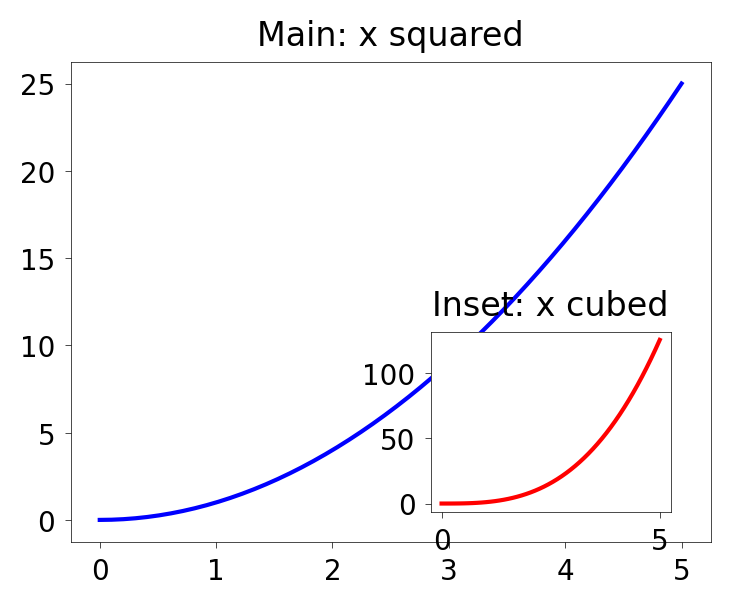

In [33]:
### Solution
import numpy as np
import matplotlib.pyplot as plt

x = np.linspace(0, 5, 50)
fig = plt.figure(figsize=(4, 3))
main_ax = fig.add_axes([0.1, 0.1, 0.8, 0.8])
main_ax.plot(x, x ** 2, color='blue')
main_ax.set_title('Main: x squared')
inset_ax = fig.add_axes([0.55, 0.15, 0.3, 0.3])
inset_ax.plot(x, x ** 3, color='red')
inset_ax.set_title('Inset: x cubed')
plt.show()

```{index} figure-level settings
```
## Figure Size, Resolution, and Saving

Three figure-level settings decide how a chart looks outside the notebook: its size in inches, its resolution in dots per inch, and the file it is saved to. These matter most when a chart goes into a report or slide deck.


```{index} figure size (figsize)
```
### `figsize=`

Figure size and DPI are two of the most common figure-level controls.

- `figsize=(width, height)` uses inches.

This can be set with `plt.figure(...)` or `plt.subplots(...)`.


Text(0.5, 1.0, 'title')

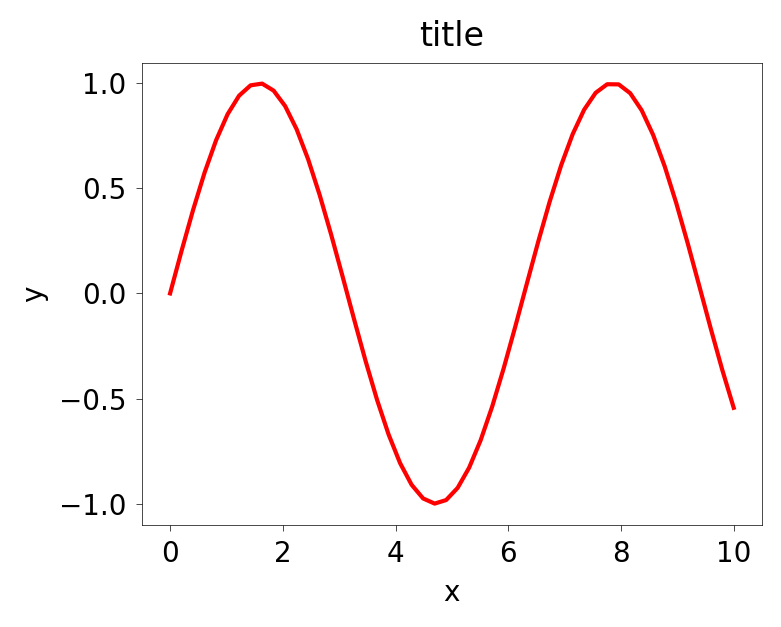

In [4]:
x = np.linspace(0, 10, 50)              ### start, stop, number of points
y = np.sin(x)

fig, axes = plt.subplots(figsize=(4,3))

### peripherals for the axes object
axes.plot(x, y, 'r')
axes.set_xlabel('x')
axes.set_ylabel('y')
axes.set_title('title')

```{index} DPI, resolution
```
### DPI

- `dpi` sets dots per inch, which affects rendered resolution.

Text(0.5, 1.0, 'title')

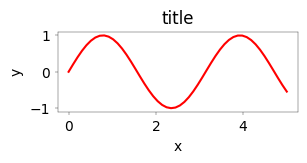

In [35]:
fig = plt.figure(figsize=(3,1), dpi=50)
axes = fig.add_axes([0.1, 0.1, 0.8, 0.8])
axes.plot(x, y, 'r')
axes.set_xlabel('x')
axes.set_ylabel('y')
axes.set_title('title')

Text(0.5, 1.0, 'title')

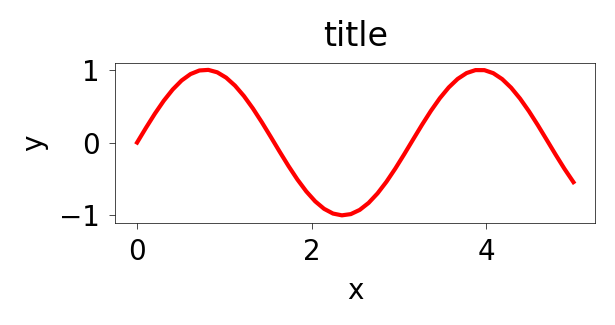

In [36]:
fig = plt.figure(figsize=(3,1), dpi=100)
axes = fig.add_axes([0.1, 0.1, 0.8, 0.8])
axes.plot(x, y, 'r')
axes.set_xlabel('x')
axes.set_ylabel('y')
axes.set_title('title')

In [37]:
### Exercise: Setting Figure Size and DPI
#   1. Create a figure with figsize=(4, 3) and dpi=150.
#   2. Add axes using fig.add_axes([0.1, 0.1, 0.8, 0.8]).
#   3. Plot x vs x**2 with a green line.
#   4. Set the title to "High-Resolution Plot".
#   (x is already defined above.)
### Your code starts here.




### Your code ends here.

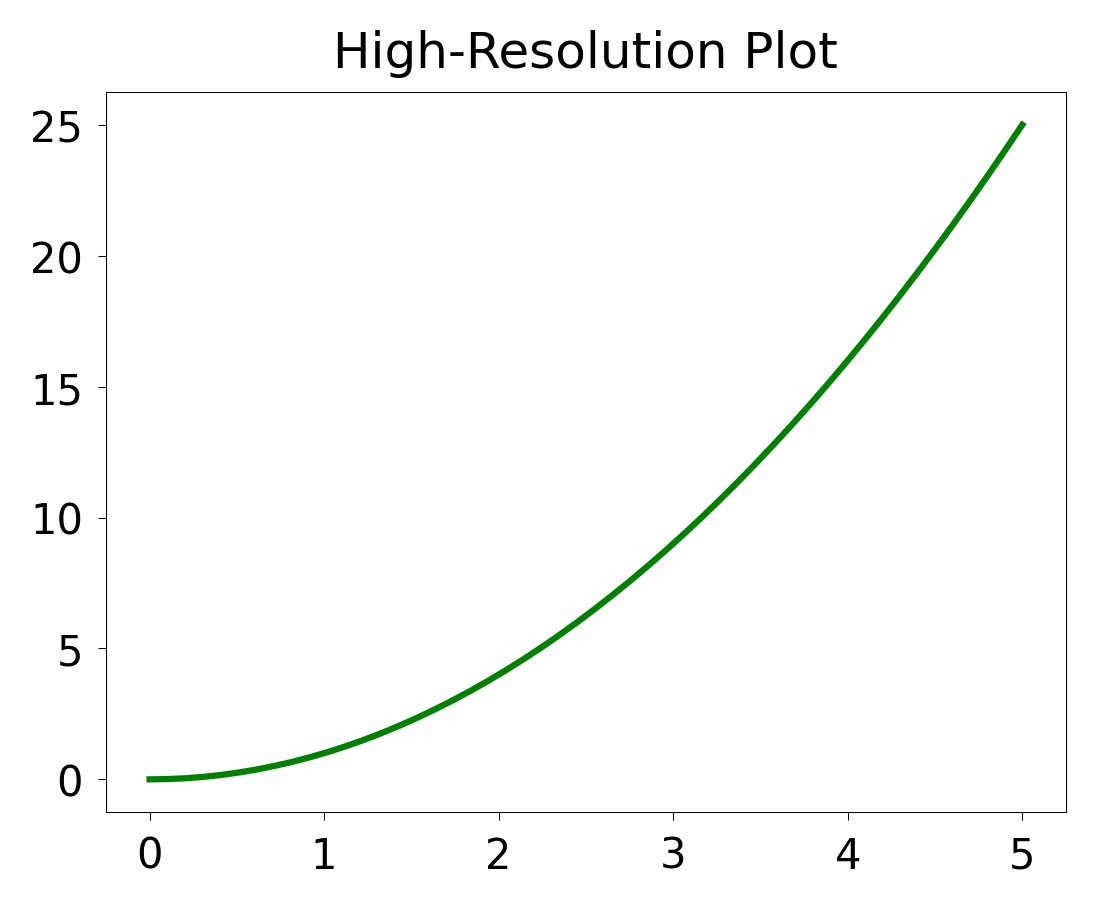

In [38]:
### Solution
import numpy as np
import matplotlib.pyplot as plt

x = np.linspace(0, 5, 50)
fig = plt.figure(figsize=(4, 3), dpi=150)
ax = fig.add_axes([0.1, 0.1, 0.8, 0.8])
ax.plot(x, x ** 2, color='green')
ax.set_title('High-Resolution Plot')
plt.show()

```{index} saving figures (savefig)
```
### Saving Figures

Matplotlib can save high-quality output in formats such as PNG, JPG, SVG, and PDF.


Use the figure's `.savefig()` method. The file type follows the extension, such as `.png`, `.pdf`, or `.svg`. Use `dpi=` to set the resolution of the saved file: the default is about 100 dots per inch, which looks fine on screen, while 200 to 300 is typical for printed reports. In the example below, we create a small figure explicitly before saving it:


Saved: ../../_build/generated/filename.png


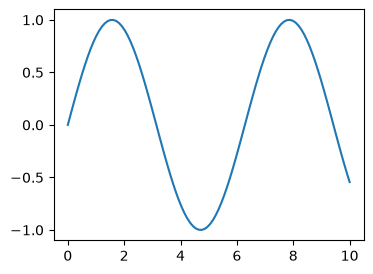

In [11]:
import os
output_dir = '../../_build/generated'
os.makedirs(output_dir, exist_ok=True)
output_file = os.path.join(output_dir, 'filename.png')


x = np.linspace(0, 10, 100)
y = np.sin(x)

fig, ax = plt.subplots(figsize=(4, 3))
ax.plot(x, y)

fig.savefig(output_file, dpi=200)     ### dpi= sets the resolution of the saved file
print(f"Saved: {output_file}")

In [ ]:
### Exercise: Save a Chart for a Report
#   1. Create quarters = ["Q1", "Q2", "Q3", "Q4"] and revenue = [120, 135, 128, 150].
#   2. Use fig, ax = plt.subplots(figsize=(6, 3)) and plot quarters vs revenue
#      with circle markers (marker='o').
#   3. Set the title "Quarterly Revenue".
#   4. Save the figure as "quarterly_revenue.png" with dpi=150.
### Your code starts here.




### Your code ends here.


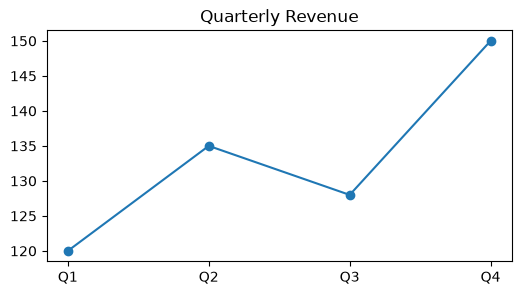

In [22]:
### Solution
quarters = ["Q1", "Q2", "Q3", "Q4"]
revenue = [120, 135, 128, 150]

fig, ax = plt.subplots(figsize=(6, 3))
ax.plot(quarters, revenue, marker='o')
ax.set_title("Quarterly Revenue")
fig.savefig("quarterly_revenue.png", dpi=150)
